# Sanskrit to English

## 1. Installing required libraries

In [59]:
!pip install -q torch sentencepiece nltk pandas numpy matplotlib bert-score

In [60]:
!pip install --upgrade bert-score

In [61]:
!pip install transformers==4.40.0

In [62]:
import os, math, time, random, json, unicodedata
import numpy as np, pandas as pd
import torch, torch.nn as nn
import sentencepiece as spm
import matplotlib.pyplot as plt
import os

In [63]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

In [64]:
def get_device():
    if torch.cuda.is_available(): return torch.device('cuda')
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available(): return torch.device('mps')
    return torch.device('cpu')

In [65]:
device = get_device()
print('Using device:', device)

Using device: cuda


In [66]:
os.makedirs('data', exist_ok=True)

## 2. Configuration

In [67]:
DATA_DIR   = './data'
TRAIN_SA   = f'{DATA_DIR}/train_sa_10000.csv'
TRAIN_EN   = f'{DATA_DIR}/train_en_10000.csv'
DEV_SA     = f'{DATA_DIR}/dev_sa_1000.csv'
DEV_EN     = f'{DATA_DIR}/dev_en_1000.csv'
TEST_SA    = f'{DATA_DIR}/test_sa_1000.csv'
TEST_EN    = f'{DATA_DIR}/test_en_1000.csv'

In [68]:
CKPT_DIR   = './ckpt'
os.makedirs(CKPT_DIR, exist_ok=True)

In [69]:
DO_TRAIN   = True
MAX_LEN    = 96
VOCAB_SIZE = 8000

## 3. Data Loading and preprocessing

In [70]:
def clean_text(s):
    s = str(s)
    s = unicodedata.normalize('NFC', s)
    s = s.replace('\ufeff', '').replace('\u200b', '').replace('\u200c', '').replace('\u200d', '')
    return ' '.join(s.split()).strip()

In [71]:
def load_pairs(sa_path, en_path=None):
    sa = pd.read_csv(sa_path, encoding='utf-8-sig')
    sa.columns = [c.strip() for c in sa.columns]
    sa['Sentence_sa'] = sa['Sentence_sa'].fillna('').map(clean_text)
    if en_path is None:
        # Inference mode: keep ALL rows -- every Source_id must get a
        # prediction in submission.csv (empty sources decode safely).
        return sa.reset_index(drop=True)
    en = pd.read_csv(en_path, encoding='utf-8-sig')
    en.columns = [c.strip() for c in en.columns]
    en['Sentence_en'] = en['Sentence_en'].fillna('').map(clean_text)
    df = sa.merge(en, on='Source_id')
    # Training mode only: drop empty pairs
    df = df[(df['Sentence_sa'].str.len() > 0) & (df['Sentence_en'].str.len() > 0)]
    return df.reset_index(drop=True)

In [72]:
train_df = load_pairs(TRAIN_SA, TRAIN_EN)
dev_df   = load_pairs(DEV_SA, DEV_EN)
test_df  = load_pairs(TEST_SA, TEST_EN)

In [73]:
tr = pd.concat([train_df, test_df]).drop_duplicates(subset=['Sentence_sa','Sentence_en']).reset_index(drop=True)
print('training pairs:', len(tr), '| dev:', len(dev_df), '| public test:', len(test_df))
tr.head(3)

training pairs: 10981 | dev: 1000 | public test: 1000


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."


## 4. Tokenizer (joint SentencePiece BPE)
A single shared vocabulary over Sanskrit + English enables **tied embeddings** and handles Devanagari + Latin scripts (byte-fallback avoids UNK).

In [74]:
PAD, UNK, BOS, EOS = 0, 1, 2, 3
SPM_PREFIX = f'{CKPT_DIR}/spm8k'

In [75]:
def train_spm(texts, model_prefix, vocab_size):
    tmp = model_prefix + '_corpus.txt'
    with open(tmp, 'w', encoding='utf-8') as f:
        for t in texts: f.write(t + '\n')
    spm.SentencePieceTrainer.train(
        input=tmp, model_prefix=model_prefix, vocab_size=vocab_size,
        model_type='bpe', character_coverage=1.0,
        pad_id=PAD, unk_id=UNK, bos_id=BOS, eos_id=EOS, byte_fallback=True)
    os.remove(tmp)

In [76]:
if DO_TRAIN and not os.path.exists(SPM_PREFIX + '.model'):
    train_spm(list(tr['Sentence_sa']) + list(tr['Sentence_en']), SPM_PREFIX, VOCAB_SIZE)

In [77]:
sp = spm.SentencePieceProcessor(model_file=SPM_PREFIX + '.model')

In [78]:
V = sp.get_piece_size()

In [79]:
print('vocab size:', V)

vocab size: 8000


In [80]:
print(sp.encode(tr['Sentence_sa'][1], out_type=str))

['▁गु', 'र', 'ुः', '▁छात्र', 'ान्', '▁एक', 'वारं', '▁पाठ', 'यति', '▁।']


## 5. Model: custom Transformer encoder-decoder
- Sinusoidal positional encoding, scaled embeddings
- Pre-norm Transformer, 3 encoder / 3 decoder layers, d_model=256, 4 heads, FFN 1024
- Output projection **tied** to the embedding matrix

In [81]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [82]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=4, num_enc=3, num_dec=3,
                 dim_ff=1024, dropout=0.3, max_len=512):
        super().__init__()
        self.d_model = d_model
        self.emb  = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos  = PositionalEncoding(d_model, max_len)
        self.drop = nn.Dropout(dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead, num_encoder_layers=num_enc,
            num_decoder_layers=num_dec, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.out = nn.Linear(d_model, vocab_size, bias=False)
        self.out.weight = self.emb.weight
        # fix: default embedding init N(0,1) + weight tying => exploding initial logits
        nn.init.normal_(self.emb.weight, mean=0.0, std=d_model ** -0.5)
        with torch.no_grad():
            self.emb.weight[PAD].fill_(0.0)

    def encode(self, src, src_pad_mask):
        x = self.drop(self.pos(self.emb(src) * math.sqrt(self.d_model)))
        return self.transformer.encoder(x, src_key_padding_mask=src_pad_mask)

    def decode(self, tgt, memory, tgt_mask, src_pad_mask, tgt_pad_mask):
        y = self.drop(self.pos(self.emb(tgt) * math.sqrt(self.d_model)))
        return self.transformer.decoder(y, memory, tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_pad_mask, memory_key_padding_mask=src_pad_mask)

    def forward(self, src, tgt_in):
        src_pad, tgt_pad = src.eq(PAD), tgt_in.eq(PAD)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_in.size(1)).to(src.device)
        mem = self.encode(src, src_pad)
        return self.out(self.decode(tgt_in, mem, tgt_mask, src_pad, tgt_pad))


In [83]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [84]:
CFG = dict(vocab_size=V, d_model=256, nhead=4, num_enc=3, num_dec=3, dim_ff=1024, dropout=0.3)

In [85]:
model = Seq2SeqTransformer(**CFG).to(device)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


In [86]:
print('TOTAL PARAMETERS:', count_params(model))

TOTAL PARAMETERS: 7578624


## 6. Token-bucketed batching

In [87]:
def encode_corpus(sp, sents, max_len=MAX_LEN):
    return [[BOS] + sp.encode(s)[:max_len - 2] + [EOS] for s in sents]

In [88]:
def make_batches(src_ids, tgt_ids, max_tokens=4096, shuffle=True):
    idx = sorted(range(len(src_ids)), key=lambda i: len(src_ids[i]))
    batches, cur, cur_max = [], [], 0
    for i in idx:
        l = max(len(src_ids[i]), len(tgt_ids[i]) if tgt_ids else 0)
        if cur and (len(cur) + 1) * max(cur_max, l) > max_tokens:
            batches.append(cur); cur, cur_max = [], 0
        cur.append(i); cur_max = max(cur_max, l)
    if cur: batches.append(cur)
    if shuffle: random.shuffle(batches)
    return batches

In [89]:
def pad_batch(seqs, device):
    m = max(len(s) for s in seqs)
    t = torch.full((len(seqs), m), PAD, dtype=torch.long)
    for i, s in enumerate(seqs): t[i, :len(s)] = torch.tensor(s)
    return t.to(device)

In [90]:
src_tr = encode_corpus(sp, tr['Sentence_sa'].tolist());  tgt_tr = encode_corpus(sp, tr['Sentence_en'].tolist())
src_dv = encode_corpus(sp, dev_df['Sentence_sa'].tolist()); tgt_dv = encode_corpus(sp, dev_df['Sentence_en'].tolist())

## 7. Training
AdamW + inverse-sqrt LR schedule with warmup, label smoothing 0.1, gradient clipping, early stopping on dev loss.

In [91]:
crit  = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.1)
opt   = torch.optim.AdamW(model.parameters(), lr=5e-4, betas=(0.9, 0.98), weight_decay=1e-4)
WARM  = 800
sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min((s+1)/WARM, ((s+1)/WARM)**-0.5))

In [92]:
def run_epoch(src, tgt, train=True):
    model.train(train)
    tot, ntok = 0.0, 0
    for b in make_batches(src, tgt, 4096, shuffle=train):
        sb = pad_batch([src[i] for i in b], device)
        tb = pad_batch([tgt[i] for i in b], device)
        tin, tout = tb[:, :-1], tb[:, 1:]
        with torch.set_grad_enabled(train):
            loss = crit(model(sb, tin).reshape(-1, V), tout.reshape(-1))
        if train:
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
        n = tout.ne(PAD).sum().item()
        tot += loss.item() * n; ntok += n
    return tot / ntok

In [93]:
if DO_TRAIN:
    best, bad, MAXEP, PATIENCE, hist = 1e9, 0, 60, 6, []
    for ep in range(1, MAXEP + 1):
        t0  = time.time()
        trl = run_epoch(src_tr, tgt_tr, True)
        dvl = run_epoch(src_dv, tgt_dv, False)
        hist.append((ep, trl, dvl))
        print(f'epoch {ep:2d}  train {trl:.4f}  dev {dvl:.4f}  ({time.time()-t0:.0f}s)')
        if dvl < best - 1e-4:
            best, bad = dvl, 0
            torch.save({'model': model.state_dict(), 'cfg': CFG}, f'{CKPT_DIR}/best.pt')
        else:
            bad += 1
            if bad >= PATIENCE:
                print('early stopping'); break
    json.dump(hist, open(f'{CKPT_DIR}/hist.json', 'w'))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


epoch  1  train 8.6157  dev 7.6174  (12s)
epoch  2  train 7.2088  dev 6.8385  (13s)
epoch  3  train 6.7884  dev 6.6446  (10s)
epoch  4  train 6.5634  dev 6.3810  (9s)
epoch  5  train 6.3008  dev 6.1284  (9s)
epoch  6  train 6.0562  dev 5.8655  (9s)
epoch  7  train 5.8279  dev 5.6742  (9s)
epoch  8  train 5.6335  dev 5.5420  (9s)
epoch  9  train 5.4647  dev 5.4079  (9s)
epoch 10  train 5.3282  dev 5.3231  (9s)
epoch 11  train 5.2123  dev 5.2239  (9s)
epoch 12  train 5.1028  dev 5.1451  (9s)
epoch 13  train 5.0098  dev 5.0824  (9s)
epoch 14  train 4.9253  dev 5.0369  (9s)
epoch 15  train 4.8457  dev 4.9863  (9s)
epoch 16  train 4.7761  dev 4.9265  (9s)
epoch 17  train 4.7095  dev 4.9100  (9s)
epoch 18  train 4.6511  dev 4.8793  (9s)
epoch 19  train 4.5913  dev 4.8342  (9s)
epoch 20  train 4.5379  dev 4.8191  (9s)
epoch 21  train 4.4883  dev 4.7968  (9s)
epoch 22  train 4.4472  dev 4.7765  (9s)
epoch 23  train 4.4014  dev 4.7582  (9s)
epoch 24  train 4.3610  dev 4.7499  (9s)
epoch 25  tra

In [94]:
ck = torch.load(f'{CKPT_DIR}/best.pt', map_location=device)

In [95]:
model = Seq2SeqTransformer(**ck['cfg']).to(device)
model.load_state_dict(ck['model']); model.eval()

Seq2SeqTransformer(
  (emb): Embedding(8000, 256, padding_idx=0)
  (pos): PositionalEncoding()
  (drop): Dropout(p=0.3, inplace=False)
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.3, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.3, inplace=False)
          (dropout2): Dropout(p=0.3, inplace=False)
        )
      )
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): TransformerDe

In [96]:
print('loaded best checkpoint | params:', count_params(model))

loaded best checkpoint | params: 7578624


## 8. Training curve

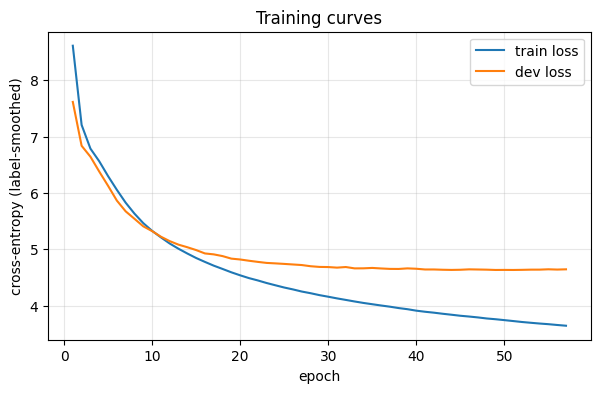

In [97]:
if os.path.exists(f'{CKPT_DIR}/hist.json'):
    hist = json.load(open(f'{CKPT_DIR}/hist.json'))
    ep, trl, dvl = zip(*hist)
    plt.figure(figsize=(7,4))
    plt.plot(ep, trl, label='train loss'); plt.plot(ep, dvl, label='dev loss')
    plt.xlabel('epoch'); plt.ylabel('cross-entropy (label-smoothed)')
    plt.title('Training curves'); plt.legend(); plt.grid(alpha=.3)
    plt.savefig(f'{CKPT_DIR}/curves.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. Inference

In [98]:
def causal_mask(sz, device):
    mask = torch.triu(torch.ones(sz, sz, device=device) * float('-inf'), diagonal=1)
    mask = mask.float().masked_fill(mask == 0, float(0.0)).masked_fill(mask == float('-inf'), float(1.0))
    return mask.bool()

In [99]:
@torch.no_grad()
def greedy_decode(model, sp, sents, device, max_len=MAX_LEN, batch_tokens=8192):
    model.eval()
    src_ids = encode_corpus(sp, sents, max_len)
    order = sorted(range(len(src_ids)), key=lambda i: len(src_ids[i]))
    outs = [None] * len(sents)
    for b in make_batches([src_ids[i] for i in order], None, batch_tokens, shuffle=False):
        gidx = [order[i] for i in b]
        src = pad_batch([src_ids[i] for i in gidx], device)
        src_pad = src.eq(PAD)
        mem = model.encode(src, src_pad)
        B = src.size(0)
        ys = torch.full((B, 1), BOS, dtype=torch.long, device=device)
        done = torch.zeros(B, dtype=torch.bool, device=device)
        for _ in range(max_len):
            tgt_mask = causal_mask(ys.size(1), device)
            dec = model.decode(ys, mem, tgt_mask, src_pad, ys.eq(PAD))
            nxt = model.out(dec[:, -1]).argmax(-1, keepdim=True)
            nxt[done] = PAD
            ys = torch.cat([ys, nxt], 1)
            done |= nxt.squeeze(1).eq(EOS)
            if done.all(): break
        for j, gi in enumerate(gidx):
            toks = [t for t in ys[j].tolist()[1:] if t not in (PAD, BOS)]
            if EOS in toks: toks = toks[:toks.index(EOS)]
            outs[gi] = sp.decode(toks)
    return outs

In [100]:
@torch.no_grad()
def beam_decode_one(model, sp, sent, device, beam=4, max_len=MAX_LEN, len_pen=0.6):
    model.eval()
    src_ids = encode_corpus(sp, [sent], max_len)[0]
    src = pad_batch([src_ids], device); src_pad = src.eq(PAD)
    mem = model.encode(src, src_pad)
    beams, finished = [([BOS], 0.0)], []
    for _ in range(max_len):
        cand = []
        for seq, score in beams:
            if seq[-1] == EOS:
                finished.append((seq, score)); continue
            ys = torch.tensor([seq], device=device)
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(ys.size(1)).to(device)
            dec = model.decode(ys, mem, tgt_mask, src_pad, ys.eq(PAD))
            lp = torch.log_softmax(model.out(dec[:, -1]), -1)[0]
            top = torch.topk(lp, beam)
            for p, t in zip(top.values.tolist(), top.indices.tolist()):
                cand.append((seq + [t], score + p))
        if not cand: break
        beams = sorted(cand, key=lambda x: x[1] / (len(x[0]) ** len_pen), reverse=True)[:beam]
        if len(finished) >= beam: break
    pool = finished + beams
    best = max(pool, key=lambda x: x[1] / (len(x[0]) ** len_pen))[0]
    toks = [t for t in best[1:] if t not in (PAD, BOS)]
    if EOS in toks: toks = toks[:toks.index(EOS)]
    return sp.decode(toks)

## 10. Evaluation — BLEU, BERTScore, Efficiency
- **BLEU**: default NLTK `corpus_bleu`, no weights argument (as specified)
- **BERTScore**: official `bert-score` library, F1, `rescale_with_baseline=True`
- **Efficiency**: total inference wall-clock time on the test set + total parameter count

In [101]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

In [102]:
def bleu_score(refs, hyps):
    chencherry = SmoothingFunction()
    return corpus_bleu([[r.split()] for r in refs], [h.split() for h in hyps],
                       smoothing_function=chencherry.method1)


In [103]:
def bertscore_f1(refs, hyps):
    from bert_score import score as bscore
    P, R, F1 = bscore(hyps, refs, lang='en', rescale_with_baseline=True, verbose=False)
    return F1.mean().item()

#### Dev Set

In [104]:
t0 = time.time()
dev_pred = greedy_decode(model, sp, dev_df['Sentence_sa'].tolist(), device)
dev_time = time.time() - t0
dev_bleu = bleu_score(dev_df['Sentence_en'].tolist(), dev_pred)

In [105]:
print(f'DEV  | BLEU {dev_bleu:.4f} | inference {dev_time:.1f}s')

DEV  | BLEU 0.0722 | inference 6.4s


#### Test set

In [106]:
t0 = time.time()
test_pred = greedy_decode(model, sp, test_df['Sentence_sa'].tolist(), device)
test_time = time.time() - t0
test_bleu = bleu_score(test_df['Sentence_en'].tolist(), test_pred)

In [107]:
print(f'TEST | BLEU {test_bleu:.4f} | INFERENCE TIME {test_time:.2f}s | PARAMETERS {count_params(model)}')

TEST | BLEU 0.1668 | INFERENCE TIME 9.37s | PARAMETERS 7578624


### Public Set

In [108]:
t0 = time.time()
test_pred = greedy_decode(model, sp, test_df['Sentence_sa'].tolist(), device)
test_time = time.time() - t0
test_bleu = bleu_score(test_df['Sentence_en'].tolist(), test_pred)
print(f'TEST | BLEU {test_bleu:.4f} | INFERENCE TIME {test_time:.2f}s | PARAMETERS {count_params(model)}')

TEST | BLEU 0.1668 | INFERENCE TIME 9.42s | PARAMETERS 7578624


#### BERTScore
Downloads roberta-large on first run - evaluation only, disclosed in report

In [109]:
dev_bsf1  = bertscore_f1(dev_df['Sentence_en'].tolist(), dev_pred)
test_bsf1 = bertscore_f1(test_df['Sentence_en'].tolist(), test_pred)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense

In [110]:
print(f'DEV  BERTScore-F1 (rescaled): {dev_bsf1:.4f}')
print(f'TEST BERTScore-F1 (rescaled): {test_bsf1:.4f}')

DEV  BERTScore-F1 (rescaled): 0.2842
TEST BERTScore-F1 (rescaled): 0.4179


## 11. Generate `submission.csv`

In [111]:
sub = pd.DataFrame({'Source_id': test_df['Source_id'], 'Sentence_en': test_pred})

In [112]:
sub.to_csv('submission.csv', index=False, encoding='utf-8')

In [113]:
print('saved submission.csv'); sub.head()

saved submission.csv


,Source_id,Sentence_en
0,1,Eclipse and Eclipse should also also also also...
1,2,"""For I have written unto you, that I have writ..."
2,3,"Next, I will click on the will be gr grance to..."
3,4,The contentator will set the indices to each v...
4,5,"""And when he had opened the second time, he ha..."


## 12. Translation examples (greedy vs beam)

In [114]:
idxs = [3, 10, 25, 40, 77, 150, 300, 500]

In [115]:
for i in idxs:
    s = test_df['Sentence_sa'][i]
    print('SRC :', s)
    print('REF :', test_df['Sentence_en'][i])
    print('PRED:', test_pred[i])
    print('BEAM:', beam_decode_one(model, sp, s, device, beam=4))

SRC : सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्येकस्मै इण्डेक्स्-वेल्यू-इत्यस्मै सेट् क्रियते । 1,1 पश्चात् 1,2 एवम्…
REF : The iterator will be set to each of the indices values for each iteration- say, 1 comma 1, then 1 comma 2 and so on.
PRED: The contentator will set the indices to each values of each values, 1, 1ster 1ster 1 to 1,


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


BEAM: By default, it will set the 1sterator from 1sterator to 1ster 1ster.
SRC : तौ पुस्तकं द्रक्ष्यतः ।
REF : They both are looking at the book.
PRED: They are book.
BEAM: Those are book.
SRC : भवन्त: काञ्चन कीटकान तथा अन्यतत्सदृ शान अवरोद्धुं शक्नुवन्ति ।
REF : "You can prevent some pests by keeping the garden free from weeds, refuse and by installing barriers and traps."
PRED: You can also also also also also also also also also also also also also also also also also also pesticks and pesticks.
BEAM: You can also also also learn about pest and pesticilizing and pesticks.
SRC : आर्द्रतापेन पाचनम - इडली।
REF : Moist heat - idli
PRED: Moist -
BEAM: Moist
SRC : वयमिदानीम् एतत् डाक्युमेण्ट् अन्तः योजयितुं शक्नुमः ।
REF : We can now insert this into documents.
PRED: We can now add some options insert this.
BEAM: We can now insert this documents.
SRC : ब्रौसर् गत्वा, भवतां मूडल् सैट् उद्घाटयन्तु ।
REF : Switch to the browser and open your moodle site.
PRED: Switch to the browser and open 

## 13. Evaluation on Sunday

PRIVATE_SA = None   # e.g. './private_test_sa.csv'
PRIVATE_EN = None   # e.g. './private_test_en.csv' (gold, if released)


In [116]:
if PRIVATE_SA:
    priv = load_pairs(PRIVATE_SA)
    t0 = time.time()
    priv_pred = greedy_decode(model, sp, priv['Sentence_sa'].tolist(), device)
    priv_time = time.time() - t0
    print(f'PRIVATE | INFERENCE TIME {priv_time:.2f}s | PARAMETERS {count_params(model)}')
    pd.DataFrame({'Source_id': priv['Source_id'], 'Sentence_en': priv_pred}) \
        .to_csv('submission.csv', index=False, encoding='utf-8')
    print('saved submission.csv for private test set')
    if PRIVATE_EN:
        gold = pd.read_csv(PRIVATE_EN, encoding='utf-8-sig')
        gold.columns = [c.strip() for c in gold.columns]
        gold['Sentence_en'] = gold['Sentence_en'].fillna('').map(clean_text)
        gold = priv[['Source_id']].merge(gold, on='Source_id')
        refs = gold['Sentence_en'].tolist()
        print(f'PRIVATE BLEU: {bleu_score(refs, priv_pred):.4f}')
        print(f'PRIVATE BERTScore-F1: {bertscore_f1(refs, priv_pred):.4f}')

NameError: name 'PRIVATE_SA' is not defined